In [ ]:
all_data = []

for sheet in excel_file.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    all_data.append(df)
df

,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type
0,2024-01-01,Raisins,South,47,844.63,Ali,Online,Wholesale
1,2024-01-01,Cashews,North,13,193.49,Raj,Online,Retail
2,2024-01-01,Cashews,West,34,249.21,Anita,Offline,Wholesale
3,2024-01-01,Cashews,North,2,29.14,Ali,Online,Retail
4,2024-01-02,Walnuts,East,36,272.86,Anita,Offline,Wholesale
...,...,...,...,...,...,...,...,...
912,2024-12-30,Walnuts,East,37,730.96,Ali,Offline,Retail
913,2024-12-31,Almonds,East,5,82.38,Meena,Offline,Wholesale
914,2024-12-31,Walnuts,North,14,80.57,Anita,Offline,Wholesale
915,2024-12-31,Walnuts,South,30,173.73,Raj,Online,Wholesale


In [ ]:
# Combine all sheets
combined_df = pd.concat(all_data, ignore_index=True)
combined_df

,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type
0,2022-01-01,Almonds,West,37,295.16,Meena,Online,Retail
1,2022-01-01,Raisins,East,14,218.39,Raj,Online,Wholesale
2,2022-01-01,Walnuts,West,45,642.71,Anita,Online,Retail
3,2022-01-02,Pistachios,South,6,32.33,Raj,Offline,Retail
4,2022-01-02,Cashews,East,41,509.45,Meena,Online,Wholesale
...,...,...,...,...,...,...,...,...
2733,2024-12-30,Walnuts,East,37,730.96,Ali,Offline,Retail
2734,2024-12-31,Almonds,East,5,82.38,Meena,Offline,Wholesale
2735,2024-12-31,Walnuts,North,14,80.57,Anita,Offline,Wholesale
2736,2024-12-31,Walnuts,South,30,173.73,Raj,Online,Wholesale


In [ ]:
# Remove rows where Revenue is missing or zero
cleaned_df = combined_df.dropna(subset=["Revenue"])
cleaned_df = cleaned_df[cleaned_df["Revenue"] != 0]
cleaned_df

,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type
0,2022-01-01,Almonds,West,37,295.16,Meena,Online,Retail
1,2022-01-01,Raisins,East,14,218.39,Raj,Online,Wholesale
2,2022-01-01,Walnuts,West,45,642.71,Anita,Online,Retail
3,2022-01-02,Pistachios,South,6,32.33,Raj,Offline,Retail
4,2022-01-02,Cashews,East,41,509.45,Meena,Online,Wholesale
...,...,...,...,...,...,...,...,...
2733,2024-12-30,Walnuts,East,37,730.96,Ali,Offline,Retail
2734,2024-12-31,Almonds,East,5,82.38,Meena,Offline,Wholesale
2735,2024-12-31,Walnuts,North,14,80.57,Anita,Offline,Wholesale
2736,2024-12-31,Walnuts,South,30,173.73,Raj,Online,Wholesale


In [ ]:
# Convert Date column to datetime
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"])
cleaned_df

,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type
0,2022-01-01,Almonds,West,37,295.16,Meena,Online,Retail
1,2022-01-01,Raisins,East,14,218.39,Raj,Online,Wholesale
2,2022-01-01,Walnuts,West,45,642.71,Anita,Online,Retail
3,2022-01-02,Pistachios,South,6,32.33,Raj,Offline,Retail
4,2022-01-02,Cashews,East,41,509.45,Meena,Online,Wholesale
...,...,...,...,...,...,...,...,...
2733,2024-12-30,Walnuts,East,37,730.96,Ali,Offline,Retail
2734,2024-12-31,Almonds,East,5,82.38,Meena,Offline,Wholesale
2735,2024-12-31,Walnuts,North,14,80.57,Anita,Offline,Wholesale
2736,2024-12-31,Walnuts,South,30,173.73,Raj,Online,Wholesale


In [ ]:
# Average units sold by product
product_avg_units = data_2023.groupby("Product")["Units_Sold"].mean()
product_avg_units

,Units_Sold
Product,
Almonds,24.635294
Cashews,24.921053
Pistachios,25.601010
Raisins,24.292135
Walnuts,27.470588


In [ ]:
# Sort regions by revenue descending
region_revenue_sorted = region_revenue.sort_values(ascending=False)
region_revenue_sorted

,Revenue
Region,
North,75593.46
West,73637.61
South,71654.33
East,67152.47


In [ ]:
# Create Month column
data_2023["Month"] = data_2023["Date"].dt.strftime("%b")
data_2023

,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type,Month
915,2023-01-01,Pistachios,East,46,772.86,Raj,Online,Retail,Jan
916,2023-01-02,Pistachios,West,5,71.34,Meena,Offline,Retail,Jan
917,2023-01-02,Cashews,East,32,579.03,Sunil,Online,Retail,Jan
918,2023-01-03,Walnuts,West,18,247.55,Raj,Online,Wholesale,Jan
919,2023-01-03,Pistachios,North,16,172.00,Ali,Online,Wholesale,Jan
...,...,...,...,...,...,...,...,...,...
1816,2023-12-30,Walnuts,East,35,391.84,Raj,Offline,Wholesale,Dec
1817,2023-12-30,Almonds,South,11,159.00,Meena,Online,Wholesale,Dec
1818,2023-12-30,Walnuts,South,23,163.23,Sunil,Offline,Wholesale,Dec
1819,2023-12-30,Pistachios,North,23,360.53,Meena,Online,Wholesale,Dec


In [ ]:
# Pivot table
pivot_table = pd.pivot_table(
    data_2023,
    values="Revenue",
    index="Product",
    columns="Month",
    aggfunc="sum",
    fill_value=0
)

print(pivot_table)

Month           Apr      Aug      Dec      Feb      Jan      Jul      Jun  \
Product                                                                     
Almonds     6703.49  4700.25  4042.30  2093.70  3421.66  5378.22  4217.03   
Cashews     6166.26  3588.71  6306.92  4464.92  6191.58  5269.63  4196.62   
Pistachios  3693.03  4231.76  4879.44  4499.41  4272.16  6031.44  6370.48   
Raisins     6463.46  3424.36  3978.77  5796.86  5615.08  3141.47  3980.81   
Walnuts     2685.22  5996.65  2784.12  6449.93  4837.81  6953.04  6529.01   

Month           Mar      May      Nov      Oct      Sep  
Product                                                  
Almonds     7040.48  4397.05  1984.25  6001.75  2887.85  
Cashews     4181.42  5613.37  2832.24  4952.09  4668.05  
Pistachios  8076.22  3852.62  5661.59  5389.75  5246.80  
Raisins     5683.00  4226.03  6165.31  3319.37  2381.64  
Walnuts     5112.66  3414.12  7636.29  4146.24  3812.08  


In [ ]:
# Top products for each month
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("\nTop Products By Revenue For Each Month")

for month in months:
    month_data = data_2023[data_2023["Month"] == month]

    top_products = (
        month_data.groupby("Product")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    print(f"\n{month}:")
    print(top_products)



Top Products By Revenue For Each Month

Jan:
Product
Cashews       6191.58
Raisins       5615.08
Walnuts       4837.81
Pistachios    4272.16
Almonds       3421.66
Name: Revenue, dtype: float64

Feb:
Product
Walnuts       6449.93
Raisins       5796.86
Pistachios    4499.41
Cashews       4464.92
Almonds       2093.70
Name: Revenue, dtype: float64

Mar:
Product
Pistachios    8076.22
Almonds       7040.48
Raisins       5683.00
Walnuts       5112.66
Cashews       4181.42
Name: Revenue, dtype: float64

Apr:
Product
Almonds       6703.49
Raisins       6463.46
Cashews       6166.26
Pistachios    3693.03
Walnuts       2685.22
Name: Revenue, dtype: float64

May:
Product
Cashews       5613.37
Almonds       4397.05
Raisins       4226.03
Pistachios    3852.62
Walnuts       3414.12
Name: Revenue, dtype: float64

Jun:
Product
Walnuts       6529.01
Pistachios    6370.48
Almonds       4217.03
Cashews       4196.62
Raisins       3980.81
Name: Revenue, dtype: float64

Jul:
Product
Walnuts       6953.04


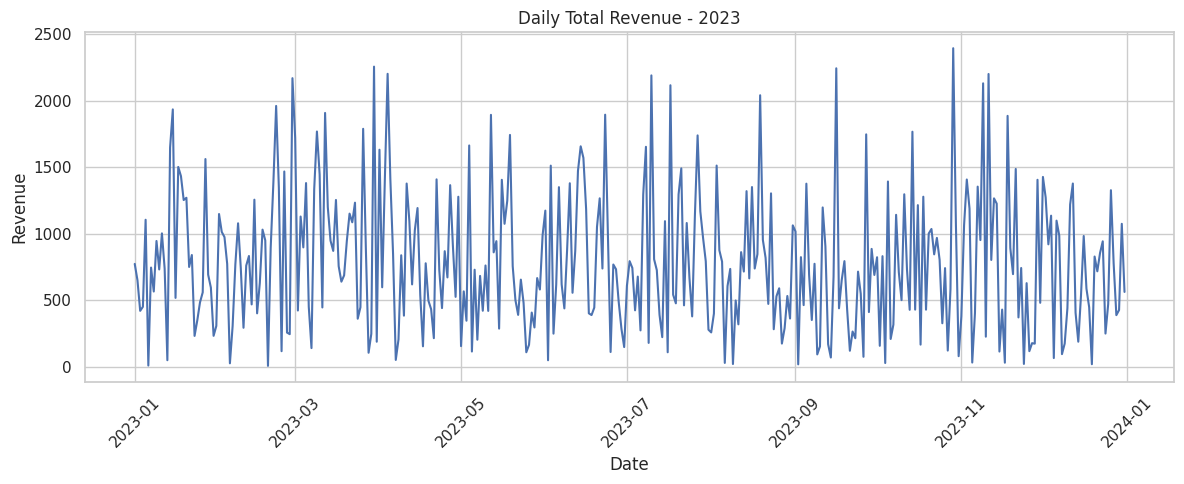

In [ ]:
# =====================================
# Question 4
# Charts using Matplotlib + Seaborn
# =====================================

sns.set_style("whitegrid")

# Daily total revenue
daily_revenue = data_2023.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_revenue.index, daily_revenue.values)
plt.title("Daily Total Revenue - 2023")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

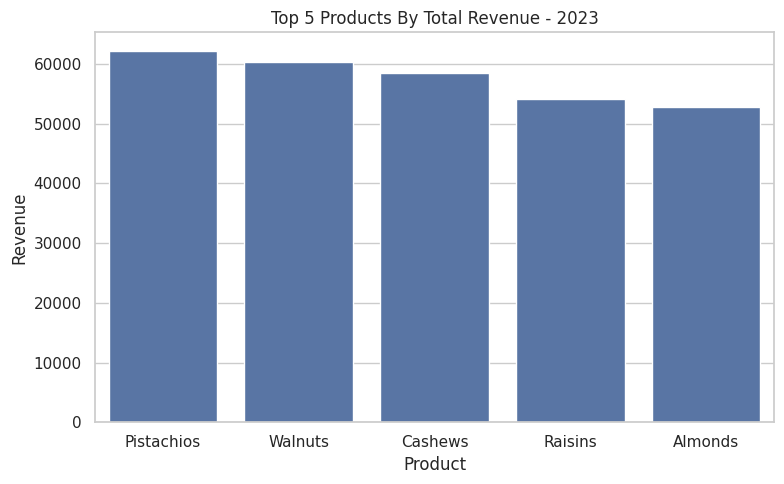

In [ ]:
# Top 5 products by total revenue
top5_products = (
    data_2023.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))
sns.barplot(x=top5_products.index, y=top5_products.values)

plt.title("Top 5 Products By Total Revenue - 2023")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

/tmp/ipykernel_673/391597224.py:256: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_673/391597224.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_673/391597224.py:339: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.96])


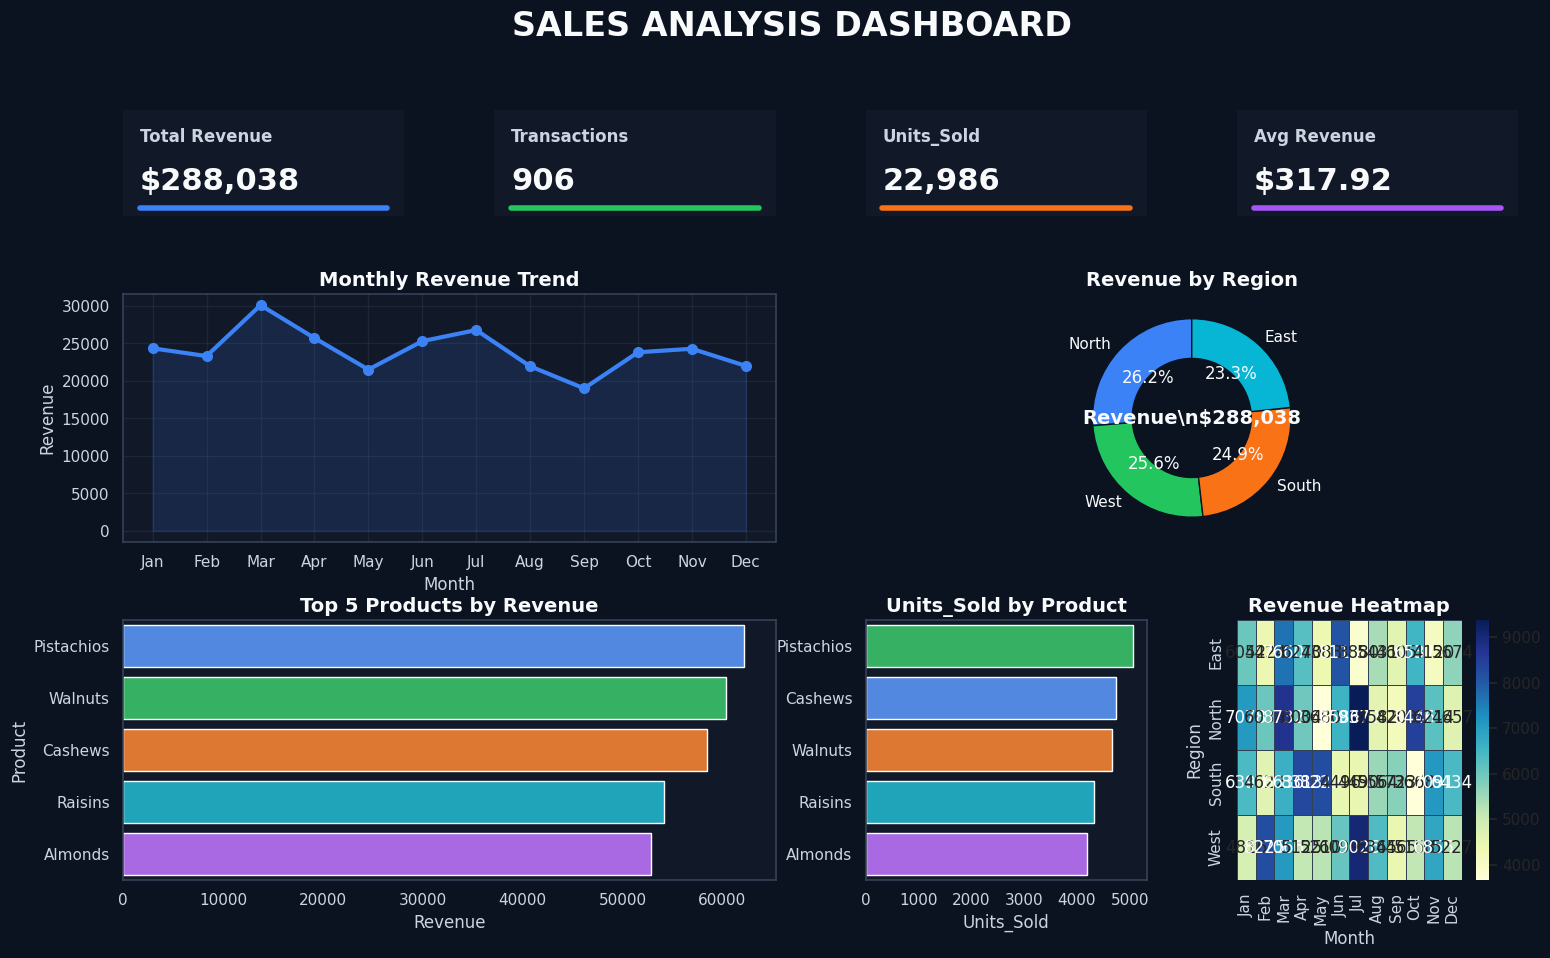

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Sales Analysis Dashboard (Professional)
# ==========================================

df = data_2023.copy()

# Create Month column
df["Month"] = df["Date"].dt.strftime("%b")

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

df["Month"] = pd.Categorical(df["Month"],
                             categories=month_order,
                             ordered=True)

# -----------------------------
# KPI Calculations
# -----------------------------
total_revenue = df["Revenue"].sum()
total_transactions = len(df)
total_units = df["Units_Sold"].sum()
avg_revenue = df["Revenue"].mean()

# -----------------------------
# Monthly Revenue
# -----------------------------
monthly_revenue = (
    df.groupby("Month", observed=False)["Revenue"]
      .sum()
      .reindex(month_order)
)

# -----------------------------
# Revenue by Region
# -----------------------------
region_revenue = (
    df.groupby("Region")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

# -----------------------------
# Top Products
# -----------------------------
top_products = (
    df.groupby("Product")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

# -----------------------------
# Units Sold by Product
# -----------------------------
units_product = (
    df.groupby("Product")["Units_Sold"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

# -----------------------------
# Heatmap
# -----------------------------
heatmap_data = pd.pivot_table(
    df,
    values="Revenue",
    index="Region",
    columns="Month",
    aggfunc="sum",
    fill_value=0,
    observed=False
).reindex(columns=month_order)

# ==========================================
# Theme
# ==========================================

BG = "#0B1220"
CARD = "#111827"
GRID = "#334155"
TEXT = "#F8FAFC"
SUB = "#CBD5E1"

BLUE = "#3B82F6"
GREEN = "#22C55E"
ORANGE = "#F97316"
PURPLE = "#A855F7"
CYAN = "#06B6D4"

sns.set_theme(style="white")

fig = plt.figure(figsize=(18,10), facecolor=BG)
gs = fig.add_gridspec(
    3, 4,
    height_ratios=[0.9, 2.1, 2.2],
    hspace=0.38,
    wspace=0.32
)

fig.suptitle(
    "SALES ANALYSIS DASHBOARD ",
    fontsize=24,
    color=TEXT,
    fontweight="bold",
    y=0.98
)

# ==========================================
# KPI Cards
# ==========================================

kpi_titles = [
    "Total Revenue",
    "Transactions",
    "Units_Sold",
    "Avg Revenue"
]

kpi_values = [
    f"${total_revenue:,.0f}",
    f"{total_transactions:,}",
    f"{total_units:,}",
    f"${avg_revenue:,.2f}"
]

kpi_colors = [BLUE, GREEN, ORANGE, PURPLE]

for i in range(4):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(CARD)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(
        0.06, 0.70,
        kpi_titles[i],
        color=SUB,
        fontsize=12,
        weight="bold",
        transform=ax.transAxes
    )

    ax.text(
        0.06, 0.25,
        kpi_values[i],
        color=TEXT,
        fontsize=22,
        weight="bold",
        transform=ax.transAxes
    )

    ax.plot(
        [0.06, 0.94],
        [0.08, 0.08],
        color=kpi_colors[i],
        linewidth=4,
        transform=ax.transAxes
    )

# ==========================================
# Monthly Revenue Trend
# ==========================================

ax1 = fig.add_subplot(gs[1, :2])
ax1.set_facecolor(CARD)

ax1.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    color=BLUE,
    linewidth=3,
    marker="o",
    markersize=7
)

ax1.fill_between(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    color=BLUE,
    alpha=0.15
)

ax1.set_title(
    "Monthly Revenue Trend",
    color=TEXT,
    fontsize=14,
    weight="bold"
)

ax1.set_xlabel("Month", color=SUB)
ax1.set_ylabel("Revenue", color=SUB)

ax1.tick_params(colors=SUB)
ax1.grid(True, color=GRID, alpha=0.35)

for spine in ax1.spines.values():
    spine.set_color(GRID)

# ==========================================
# Revenue by Region (Donut)
# ==========================================

ax2 = fig.add_subplot(gs[1, 2:])
ax2.set_facecolor(CARD)

pie_colors = [BLUE, GREEN, ORANGE, CYAN, PURPLE]

wedges, texts, autotexts = ax2.pie(
    region_revenue.values,
    labels=region_revenue.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=pie_colors,
    wedgeprops=dict(width=0.40, edgecolor=BG)
)

for t in texts:
    t.set_color(TEXT)

for t in autotexts:
    t.set_color(TEXT)

ax2.text(
    0, 0,
    f"Revenue\\n${total_revenue:,.0f}",
    ha="center",
    va="center",
    color=TEXT,
    fontsize=14,
    weight="bold"
)

ax2.set_title(
    "Revenue by Region",
    color=TEXT,
    fontsize=14,
    weight="bold"
)

# ==========================================
# Top 5 Products
# ==========================================

ax3 = fig.add_subplot(gs[2, :2])
ax3.set_facecolor(CARD)

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    ax=ax3,
    palette=[BLUE, GREEN, ORANGE, CYAN, PURPLE]
)

ax3.set_title(
    "Top 5 Products by Revenue",
    color=TEXT,
    fontsize=14,
    weight="bold"
)

ax3.set_xlabel("Revenue", color=SUB)
ax3.set_ylabel("Product", color=SUB)

ax3.tick_params(colors=SUB)

for spine in ax3.spines.values():
    spine.set_color(GRID)

# ==========================================
# Units Sold by Product
# ==========================================

ax4 = fig.add_subplot(gs[2, 2])

ax4.set_facecolor(CARD)

sns.barplot(
    x=units_product.values,
    y=units_product.index,
    ax=ax4,
    palette=[GREEN, BLUE, ORANGE, CYAN, PURPLE]
)

ax4.set_title(
    "Units_Sold by Product",
    color=TEXT,
    fontsize=14,
    weight="bold"
)

ax4.set_xlabel("Units_Sold", color=SUB)
ax4.set_ylabel("")

ax4.tick_params(colors=SUB)

for spine in ax4.spines.values():
    spine.set_color(GRID)

# ==========================================
# Heatmap
# ==========================================

ax5 = fig.add_subplot(gs[2, 3])

ax5.set_facecolor(CARD)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor=GRID,
    cbar=True,
    ax=ax5
)

ax5.set_title(
    "Revenue Heatmap",
    color=TEXT,
    fontsize=14,
    weight="bold"
)

ax5.set_xlabel("Month", color=SUB)
ax5.set_ylabel("Region", color=SUB)

ax5.tick_params(colors=SUB)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()